In [11]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
filename = '/kaggle/input/student-performance-dataset/student_performance.csv'
df = pd.read_csv(filename)
df

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A
...,...,...,...,...,...,...
999995,999996,18.0,95.5,4.8,100.0,A
999996,999997,15.7,82.7,6.7,88.3,A
999997,999998,14.2,85.1,5.8,87.9,A
999998,999999,25.3,90.0,5.3,100.0,A


In [13]:
df.isnull().sum()

student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64

In [14]:
df.drop('student_id', axis=1, inplace=True)
df

,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,18.5,95.6,3.8,97.9,A
1,14.0,80.0,2.5,83.9,B
2,19.5,86.3,5.3,100.0,A
3,25.7,70.2,7.0,100.0,A
4,13.4,81.9,6.9,92.0,A
...,...,...,...,...,...
999995,18.0,95.5,4.8,100.0,A
999996,15.7,82.7,6.7,88.3,A
999997,14.2,85.1,5.8,87.9,A
999998,25.3,90.0,5.3,100.0,A


In [15]:
df.describe()

,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,15.029127,84.711046,5.985203,84.283845
std,6.899431,9.424143,1.956421,15.432969
min,0.000000,50.000000,0.000000,9.400000
25%,10.300000,78.300000,4.700000,73.900000
50%,15.000000,85.000000,6.000000,87.500000
75%,19.700000,91.800000,7.300000,100.000000
max,40.000000,100.000000,10.000000,100.000000


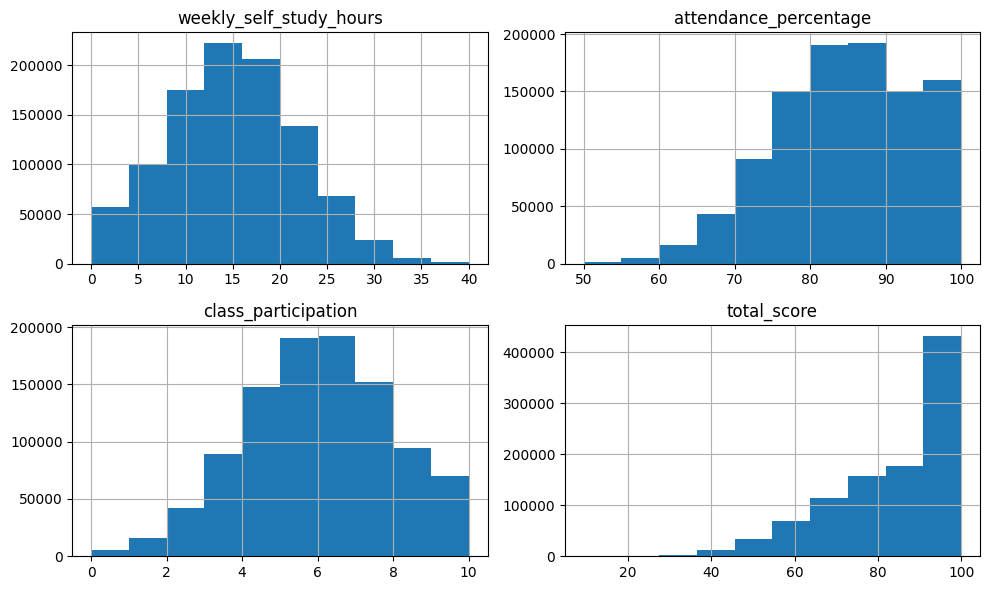

In [16]:
df.hist(bins=10, figsize=(10, 6))
plt.tight_layout()
plt.show()

                         weekly_self_study_hours  attendance_percentage  \
weekly_self_study_hours                 1.000000              -0.001008   
attendance_percentage                  -0.001008               1.000000   
class_participation                     0.001244              -0.000043   
total_score                             0.812241              -0.001014   

                         class_participation  total_score  
weekly_self_study_hours             0.001244     0.812241  
attendance_percentage              -0.000043    -0.001014  
class_participation                 1.000000     0.000684  
total_score                         0.000684     1.000000  


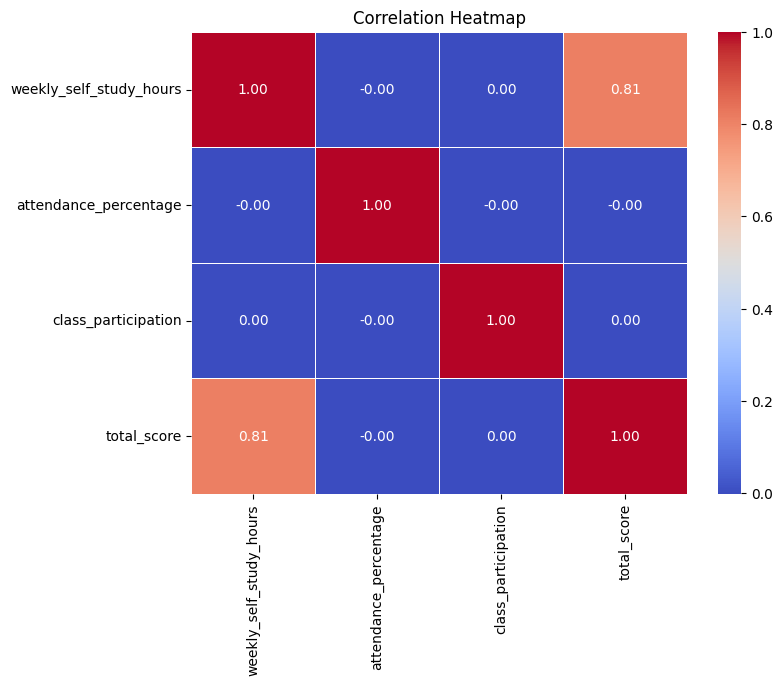

In [17]:
cols = ['weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score']
corr = df[cols].corr()
print(corr)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

/tmp/ipykernel_36/4035365333.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='grade', y='total_score', data=df, estimator='mean', ci=None)


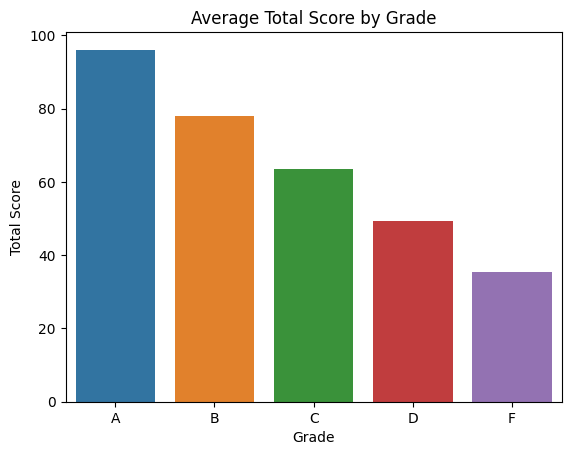

In [18]:
sns.barplot(x='grade', y='total_score', data=df, estimator='mean', ci=None)
plt.title('Average Total Score by Grade')
plt.xlabel('Grade')
plt.ylabel('Total Score')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


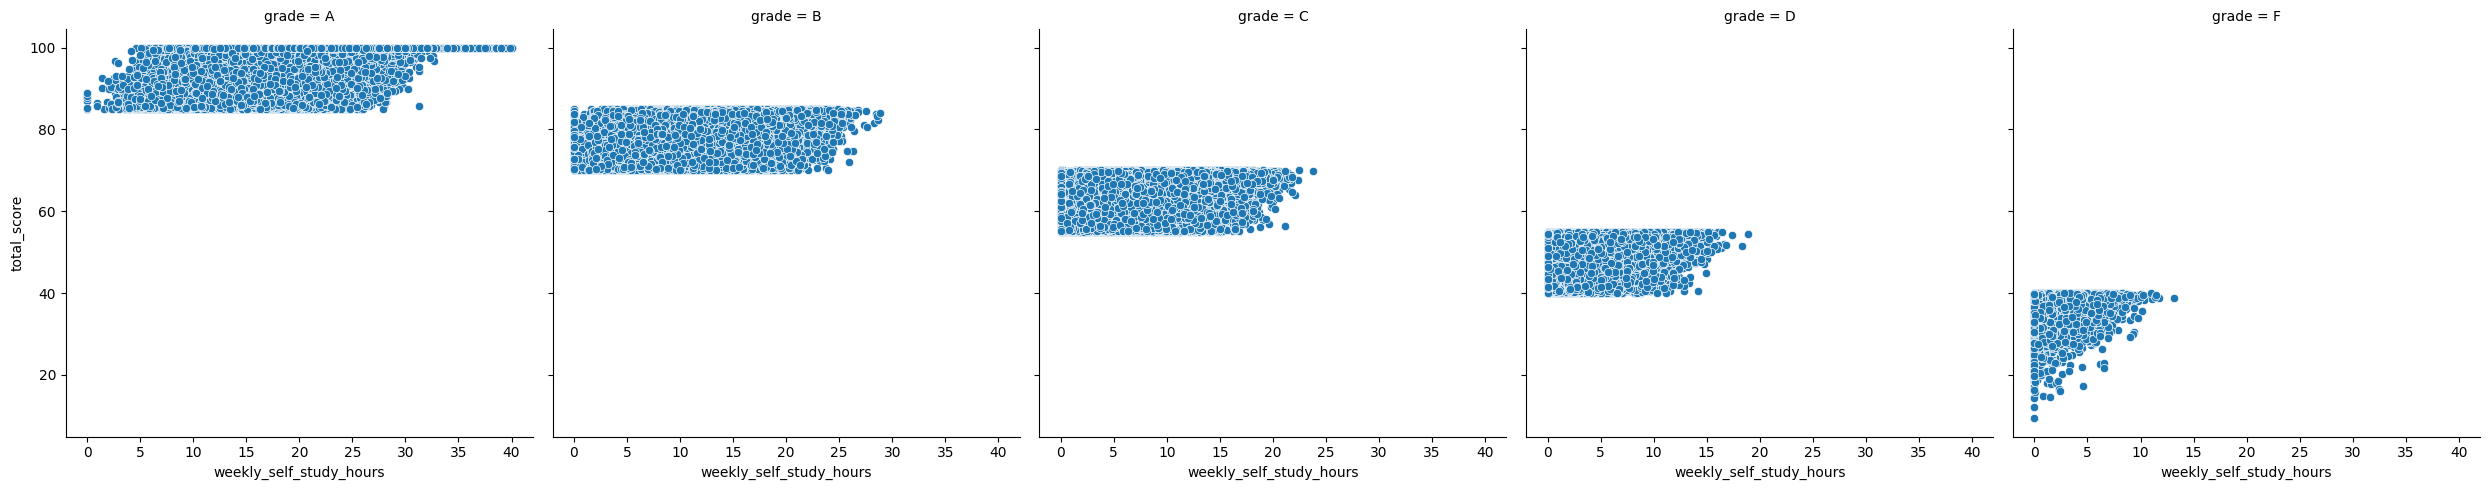

In [19]:
sns.relplot(
    data=df,
    x="weekly_self_study_hours", y="total_score", col="grade"
)

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


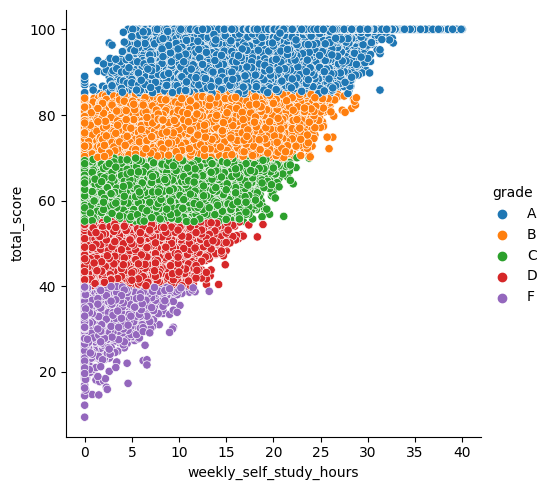

In [20]:
sns.relplot(
    data=df,
    x="weekly_self_study_hours", y="total_score", hue="grade"
)

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


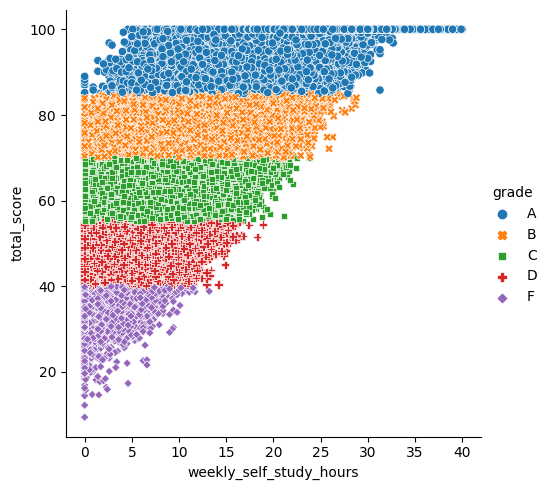

In [21]:
sns.relplot(
    data=df,
    x="weekly_self_study_hours", y="total_score", hue="grade", style="grade"
)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


ValueError: Unrecognized marker style '-'

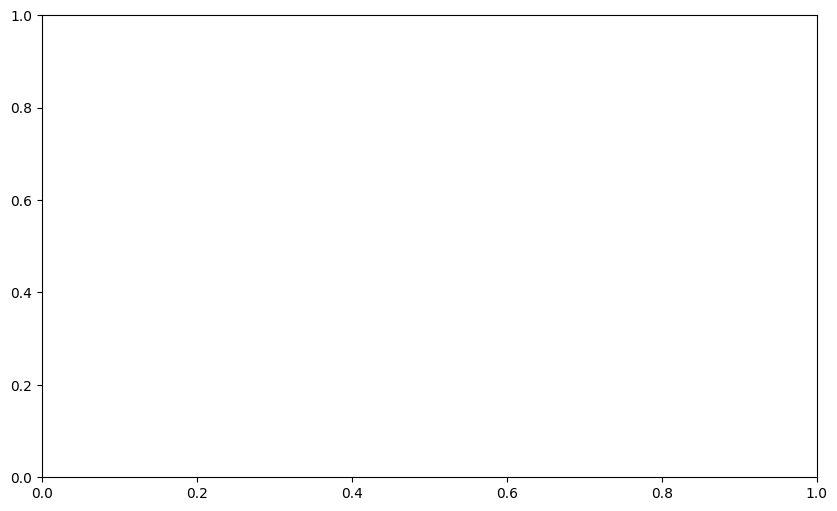

In [22]:

# Melt the DataFrame while keeping weekly_self_study_hours as identifier
df_long = pd.melt(
    df,
    id_vars='weekly_self_study_hours',
    value_vars=['total_score', 'attendance_percentage'],
    var_name='Metric',
    value_name='Value'
)

# Plot line graph with weekly_self_study_hours on x-axis
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_long, x='weekly_self_study_hours', y='Value', hue='Metric', marker='-')
plt.title('Total Score and Class Participation vs. Weekly Study Hours')
plt.xlabel('Weekly Study Hours')
plt.ylabel('Value')
plt.grid(True)
plt.show()


In [ ]:
sns.set_style("whitegrid")
custom_palette = sns.color_palette("husl", 8)
sns.set_palette(custom_palette)

sns.pairplot(df)
plt.show()